# V1 — Vintage-Level Calibration Analysis

Diagnostic notebook for understanding whether the V1 mortgage credit-risk model maintains stable probability calibration across vintages 2015–2019.

**Scope:** diagnostic only. This notebook does not retrain, recalibrate, optimize thresholds, or modify the production pipeline.


## Objective

We observed a large difference in event prevalence between development/validation vintages (2015–2017) and OOT vintages (2018–2019).

For each vintage we will examine:

- population size
- actual event rate
- average predicted PD
- calibration gap
- calibration intercept
- calibration slope
- ROC-AUC
- PR-AUC
- Brier score
- log loss


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)

from credit_risk.evaluations.risks import calculate_calibration_summary
from credit_risk.utils.config import create_path
from credit_risk.modelling.artifacts import load_model_artifacts
import os
PROJECT_ROOT = Path.cwd().parent.resolve()
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)


Project root: C:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk


## Load project configuration

The notebook uses the project's configuration and catalog instead of hard-coding data locations.


In [2]:
PARAMETERS_PATH = PROJECT_ROOT / "config" / "parameters" / "base.yml"
CATALOG_PATH = PROJECT_ROOT / "config" / "catalog" / "base.yml"

with PARAMETERS_PATH.open("r", encoding="utf-8") as file:
    parameters = yaml.safe_load(file)

with CATALOG_PATH.open("r", encoding="utf-8") as file:
    catalog = yaml.safe_load(file)

config = {**parameters, **catalog}

data_config = config["parameters"]["data"]
approach = config["parameters"]["modelling_approach"]
provider = data_config["data_provider"]

validation_vintages = [int(v) for v in config["parameters"]["modelling"]["vintages_train"]]
oot_vintages = [int(v) for v in config["parameters"]["modelling"]["vintages_oot"]]
all_vintages = validation_vintages + oot_vintages

print("Approach:", approach)
print("Provider:", provider)
print("Validation vintages:", validation_vintages)
print("OOT vintages:", oot_vintages)

Approach: origination
Provider: freddie_mac
Validation vintages: [2015, 2016, 2017]
OOT vintages: [2018, 2019]


## Load model-input populations

Each persisted model-input dataset already contains the origination-time features and target. We add `vintage` explicitly for this diagnostic.


In [3]:
model_input_paths = {}

for vintage in all_vintages:
    path = create_path(
        config["catalog"]["base"],
        config["catalog"],
        "model_input_path",
        approach,
        provider,
        vintage,
        must_exist=True,
    )
    model_input_paths[vintage] = path

population_frames = []

for vintage, path in model_input_paths.items():
    df = pd.read_parquet(path).copy()
    df["vintage"] = vintage
    population_frames.append(df)

population = pd.concat(population_frames, ignore_index=True)

target_column = "ever_90dpd_24m"

print("Rows:", f"{len(population):,}")
print("Columns:", population.shape[1])
print("Vintages:", sorted(population["vintage"].unique()))


Rows: 239,492
Columns: 27
Vintages: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]


## Load the saved V1 model and preprocessor

This notebook scores the existing artifact. It does not retrain anything.


### Resolve artifact files

The exact filenames are read from the artifact directory. If the project uses different names, inspect the printed candidates and set the two variables explicitly.


In [4]:
model, preprocessor = load_model_artifacts(config)

## Resolve the saved feature contract

Use the saved training feature contract when available. Otherwise fall back to the active configured feature list.


In [15]:
artifact_root = Path("data/05_artifacts/origination/test_unbalanced/xgboost")
metadata_candidates = [
    artifact_root / "training_metadata.json",
]

metadata_path = next(
    (p for p in metadata_candidates if p.exists()),
    None,
)

metadata = None

if metadata_path is not None:
    if metadata_path.suffix == ".json":
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    else:
        metadata = yaml.safe_load(metadata_path.read_text(encoding="utf-8"))

print("Metadata:", metadata_path)

features = None

if isinstance(metadata, dict):
    candidates = [
        ("features",),
        ("training", "features"),
        ("modeling", "features"),
        ("modelling", "features"),
    ]

    for key_path in candidates:
        value = metadata
        for key in key_path:
            if not isinstance(value, dict) or key not in value:
                value = None
                break
            value = value[key]

        if isinstance(value, list):
            features = value
            break

if features is None:
    features = config["parameters"]["modelling"]["features"]
features = list(features.values())
features = [item for sublist in features for item in sublist]
print(features)
missing_features = [
    feature for feature in features
    if feature not in population.columns
]

if missing_features:
    raise KeyError(
        f"Missing model features: {missing_features}"
    )

print("Feature count:", len(features))

Metadata: data\05_artifacts\origination\test_unbalanced\xgboost\training_metadata.json
['original_dti', 'number_of_borrowers', 'mi_percentage', 'original_upb', 'original_interest_rate', 'original_loan_term', 'original_upb_log', 'first_time_homebuyer_flag', 'property_type', 'occupancy_status', 'loan_purpose', 'channel', 'super_conforming_flag', 'harp_indicator', 'property_state', 'msa', 'credit_score_bins', 'original_ltv_bins', 'original_cltv_bins', 'original_dti_missing']
Feature count: 20


## Generate raw V1 probabilities

No calibration and no thresholding are applied.


In [16]:
X = population[features]
y = population[target_column].astype(int)

X_transformed = preprocessor.transform(X)

y_proba = np.asarray(
    model.predict_proba(X_transformed)[:, 1],
    dtype=float,
)

if len(y_proba) != len(population):
    raise ValueError("Prediction count does not match population size.")

if not np.isfinite(y_proba).all():
    raise ValueError("Predicted probabilities contain non-finite values.")

if ((y_proba < 0) | (y_proba > 1)).any():
    raise ValueError("Predicted probabilities must be between 0 and 1.")

population["predicted_pd"] = y_proba

print("Predictions generated:", f"{len(y_proba):,}")


Predictions generated: 239,492


## Overall sanity check

This should reproduce the broad validation/OOT probability behaviour that motivated the vintage investigation.


In [17]:
overall_summary = pd.DataFrame([{
    "population": len(population),
    "events": int(y.sum()),
    "actual_event_rate": y.mean(),
    "average_predicted_pd": y_proba.mean(),
    "calibration_gap": y.mean() - y_proba.mean(),
}])

overall_summary


,population,events,actual_event_rate,average_predicted_pd,calibration_gap
0,239492,4796,0.020026,0.035224,-0.015198


## Vintage-level calibration and model performance


In [18]:
rows = []

for vintage_value, group in population.groupby("vintage", sort=True):
    y_v = group[target_column].to_numpy(dtype=int)
    p_v = group["predicted_pd"].to_numpy(dtype=float)

    actual = float(y_v.mean())
    predicted = float(p_v.mean())

    row = {
        "vintage": int(vintage_value),
        "population": len(group),
        "events": int(y_v.sum()),
        "actual_event_rate": actual,
        "average_predicted_pd": predicted,
        "calibration_gap": actual - predicted,
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "brier_score": brier_score_loss(y_v, p_v),
        "log_loss": log_loss(y_v, p_v, labels=[0, 1]),
        "calibration_intercept": np.nan,
        "calibration_slope": np.nan,
    }

    if np.unique(y_v).size >= 2:
        row["roc_auc"] = roc_auc_score(y_v, p_v)
        row["pr_auc"] = average_precision_score(y_v, p_v)

        calibration = calculate_calibration_summary(
            y_true=y_v,
            y_proba=p_v,
        )

        row.update(calibration)

    rows.append(row)

vintage_summary = pd.DataFrame(rows)
vintage_summary


c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penal

,vintage,population,events,actual_event_rate,average_predicted_pd,calibration_gap,roc_auc,pr_auc,brier_score,log_loss,calibration_intercept,calibration_slope
0,2015,47255,343,0.007258,0.029641,-0.022382,0.848483,0.051061,0.008518,0.049466,-1.232556,1.101524
1,2016,48046,401,0.008346,0.027413,-0.019067,0.869528,0.076762,0.008936,0.049168,-0.721277,1.207246
2,2017,48242,509,0.010551,0.037249,-0.026698,0.854422,0.086624,0.011758,0.063054,-0.909954,1.186861
3,2018,47394,1287,0.027155,0.046980,-0.019825,0.731638,0.071481,0.027542,0.122211,-1.287189,0.733572
4,2019,48555,2256,0.046463,0.034899,0.011564,0.698889,0.098610,0.043853,0.183394,-0.873695,0.601898


## Readable summary

Event-rate, predicted-PD, and calibration-gap columns are shown as percentages. Calibration intercept and slope remain on their native scales.


In [19]:
display_summary = vintage_summary.copy()

for column in [
    "actual_event_rate",
    "average_predicted_pd",
    "calibration_gap",
]:
    display_summary[column] *= 100

display_summary.round({
    "actual_event_rate": 3,
    "average_predicted_pd": 3,
    "calibration_gap": 3,
    "roc_auc": 4,
    "pr_auc": 4,
    "brier_score": 5,
    "log_loss": 5,
    "calibration_intercept": 4,
    "calibration_slope": 4,
})


,vintage,population,events,actual_event_rate,average_predicted_pd,calibration_gap,roc_auc,pr_auc,brier_score,log_loss,calibration_intercept,calibration_slope
0,2015,47255,343,0.726,2.964,-2.238,0.8485,0.0511,0.00852,0.04947,-1.2326,1.1015
1,2016,48046,401,0.835,2.741,-1.907,0.8695,0.0768,0.00894,0.04917,-0.7213,1.2072
2,2017,48242,509,1.055,3.725,-2.670,0.8544,0.0866,0.01176,0.06305,-0.9100,1.1869
3,2018,47394,1287,2.716,4.698,-1.982,0.7316,0.0715,0.02754,0.12221,-1.2872,0.7336
4,2019,48555,2256,4.646,3.490,1.156,0.6989,0.0986,0.04385,0.18339,-0.8737,0.6019


## Plot — Actual event rate vs average predicted PD


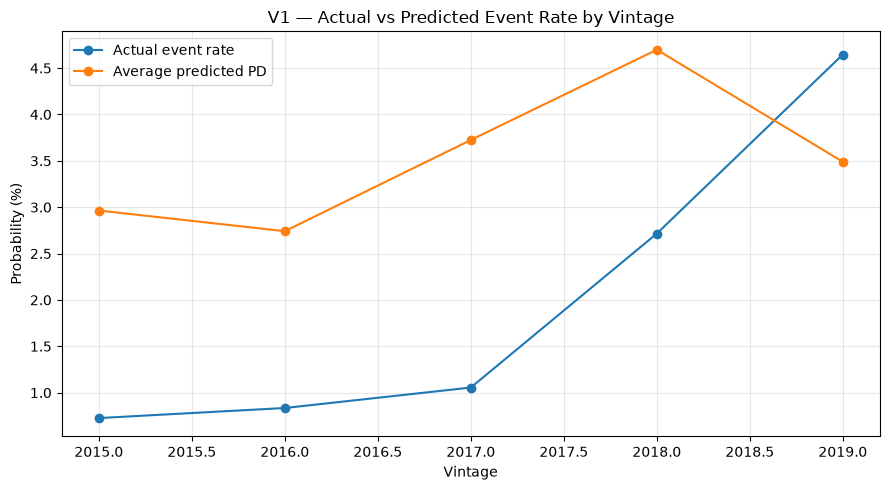

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    vintage_summary["vintage"],
    vintage_summary["actual_event_rate"] * 100,
    marker="o",
    label="Actual event rate",
)

ax.plot(
    vintage_summary["vintage"],
    vintage_summary["average_predicted_pd"] * 100,
    marker="o",
    label="Average predicted PD",
)

ax.set_xlabel("Vintage")
ax.set_ylabel("Probability (%)")
ax.set_title("V1 — Actual vs Predicted Event Rate by Vintage")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()


## Plot — Calibration gap by vintage

`Calibration gap = actual event rate − average predicted PD`.

A value near zero means population-level probability alignment for that vintage.


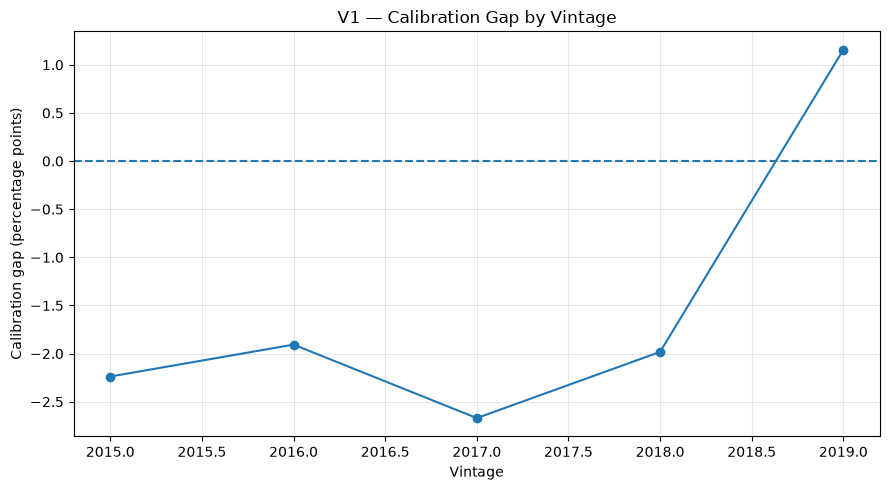

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.axhline(0, linestyle="--")

ax.plot(
    vintage_summary["vintage"],
    vintage_summary["calibration_gap"] * 100,
    marker="o",
)

ax.set_xlabel("Vintage")
ax.set_ylabel("Calibration gap (percentage points)")
ax.set_title("V1 — Calibration Gap by Vintage")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()


## Plot — Calibration slope by vintage

Ideal calibration slope is approximately `1`.


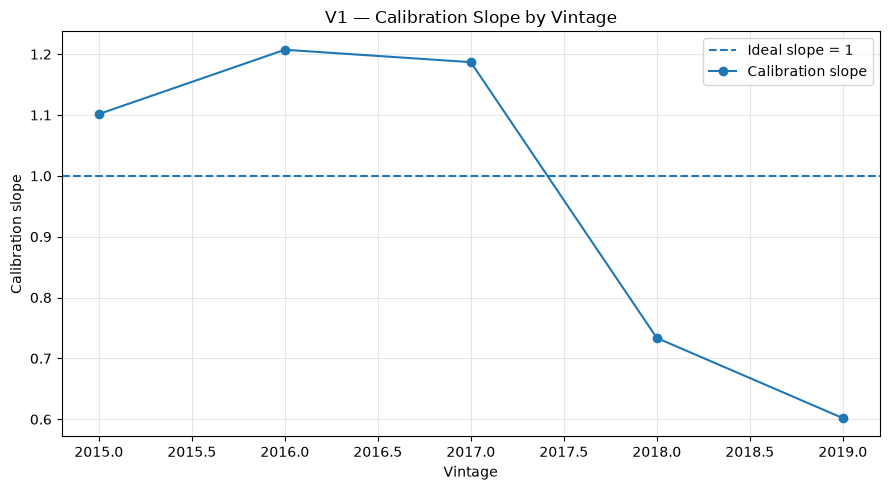

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.axhline(1.0, linestyle="--", label="Ideal slope = 1")

ax.plot(
    vintage_summary["vintage"],
    vintage_summary["calibration_slope"],
    marker="o",
    label="Calibration slope",
)

ax.set_xlabel("Vintage")
ax.set_ylabel("Calibration slope")
ax.set_title("V1 — Calibration Slope by Vintage")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()


## Plot — Calibration intercept by vintage

Ideal calibration intercept is approximately `0`.


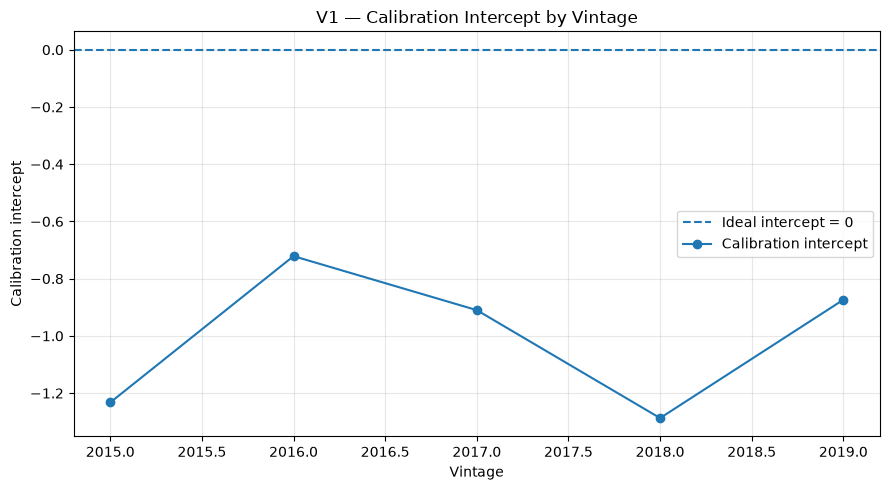

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.axhline(0.0, linestyle="--", label="Ideal intercept = 0")

ax.plot(
    vintage_summary["vintage"],
    vintage_summary["calibration_intercept"],
    marker="o",
    label="Calibration intercept",
)

ax.set_xlabel("Vintage")
ax.set_ylabel("Calibration intercept")
ax.set_title("V1 — Calibration Intercept by Vintage")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()


## Validation vs OOT comparison


In [24]:
def population_type(vintage):
    if vintage in validation_vintages:
        return "Validation"
    if vintage in oot_vintages:
        return "OOT"
    return "Other"

population["population_type"] = population["vintage"].map(population_type)

population_summary = (
    population
    .groupby("population_type")
    .agg(
        population=(target_column, "size"),
        events=(target_column, "sum"),
        actual_event_rate=(target_column, "mean"),
        average_predicted_pd=("predicted_pd", "mean"),
    )
    .reset_index()
)

population_summary["calibration_gap"] = (
    population_summary["actual_event_rate"]
    - population_summary["average_predicted_pd"]
)

population_summary


,population_type,population,events,actual_event_rate,average_predicted_pd,calibration_gap
0,OOT,95949,3543,0.036926,0.040866,-0.003940
1,Validation,143543,1253,0.008729,0.031452,-0.022723


## Final diagnostic questions

Use the outputs above to answer:

1. Does actual event prevalence change materially from 2015 → 2019?
2. Does average predicted PD follow that change?
3. Is the calibration gap stable or does it drift?
4. Does calibration slope remain near 1?
5. Is there a break between 2015–2017 and 2018–2019?
6. Is the problem primarily probability level, probability spread, or both?

**Do not fit a calibration model from this notebook yet.**

The next V1 decision should be based on these results: whether recalibration is justified and whether a single global calibration mapping is appropriate across vintages.
